
Shape of dataset (rows, columns): (50000, 32)

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              

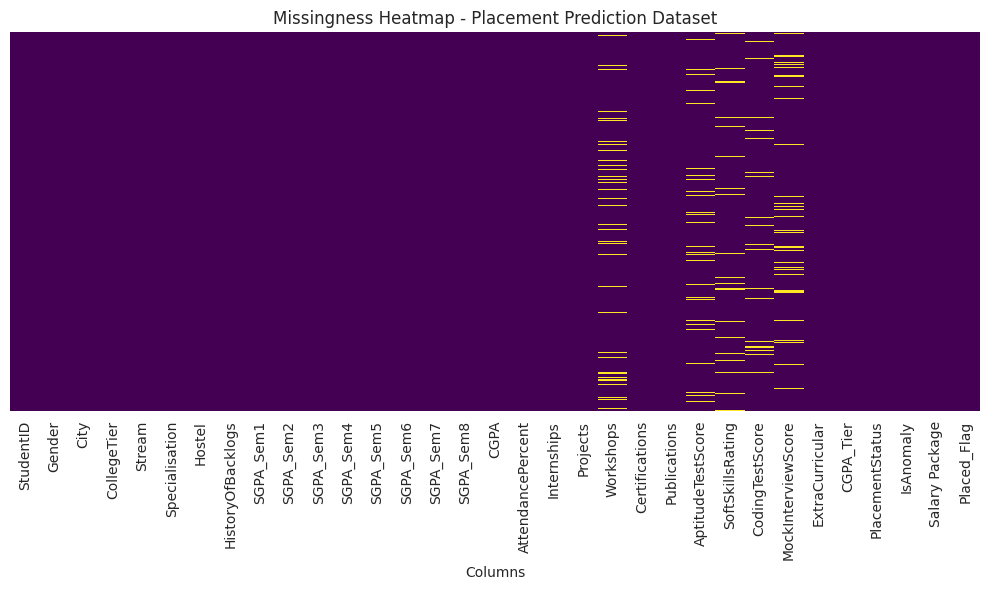

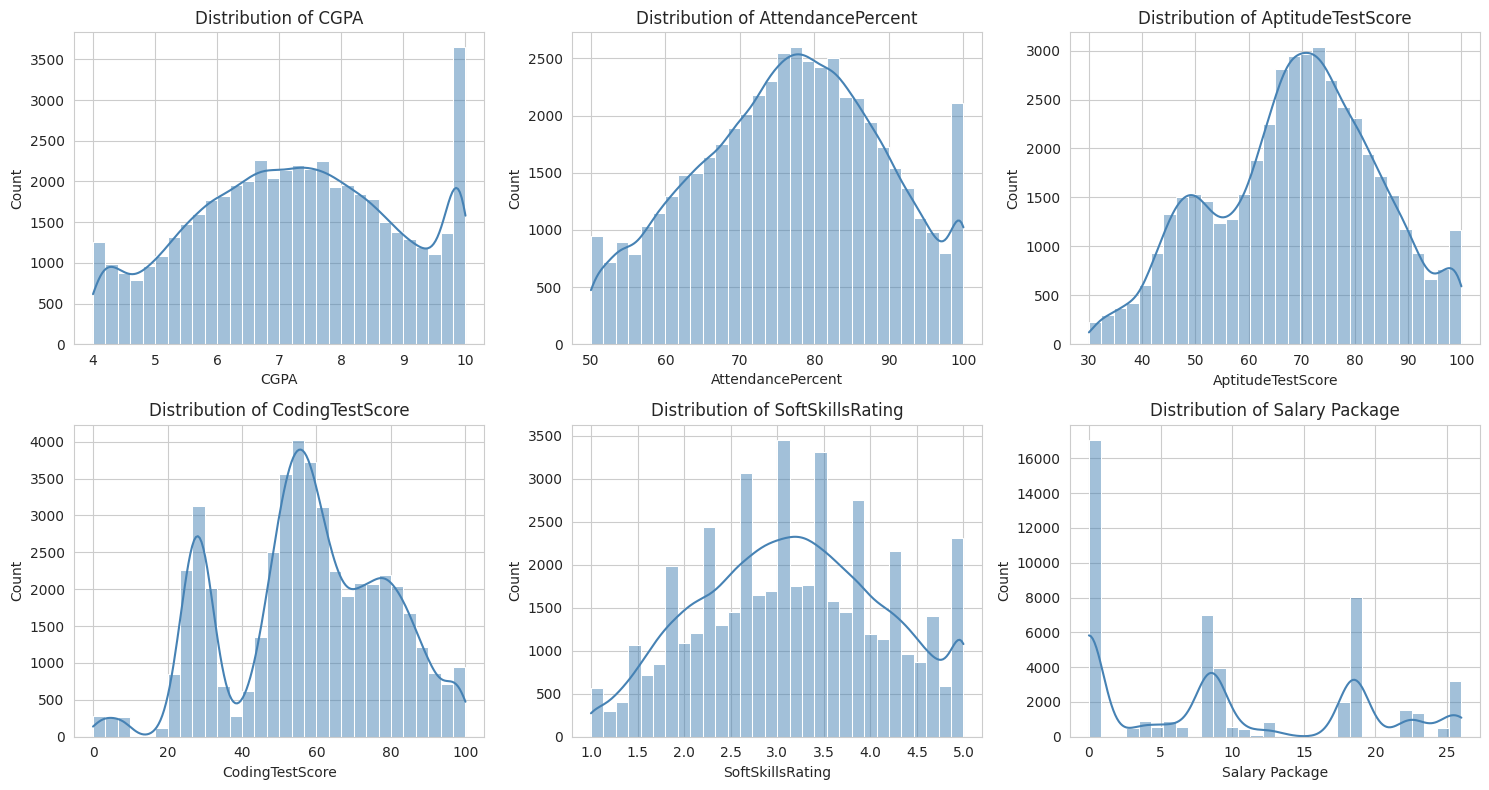

/tmp/ipykernel_529/373424330.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')


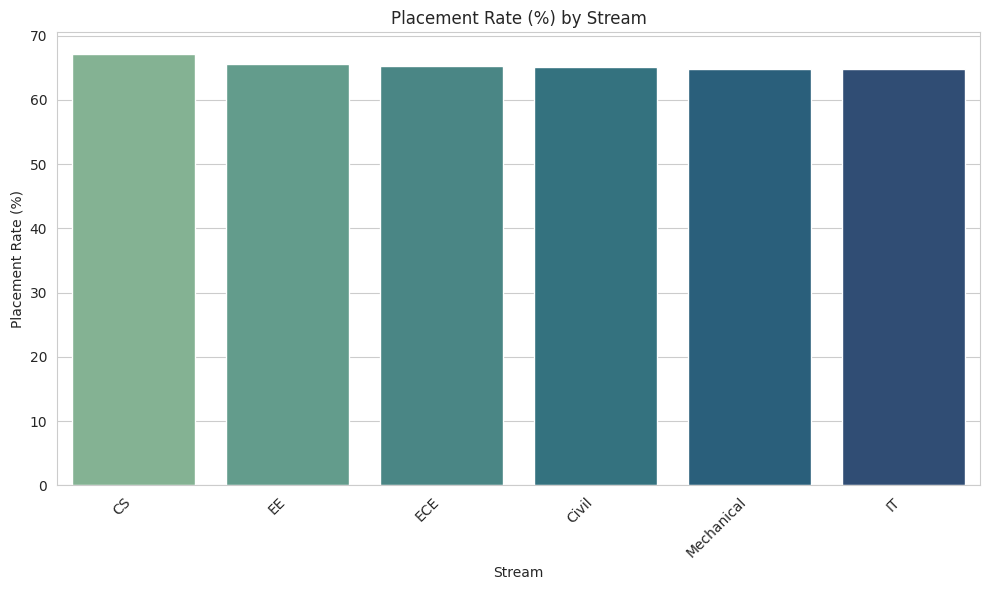


Placement rate (%) by stream:
Stream
CS            67.17
EE            65.64
ECE           65.32
Civil         65.15
Mechanical    64.88
IT            64.86
Name: Placed_Flag, dtype: float64


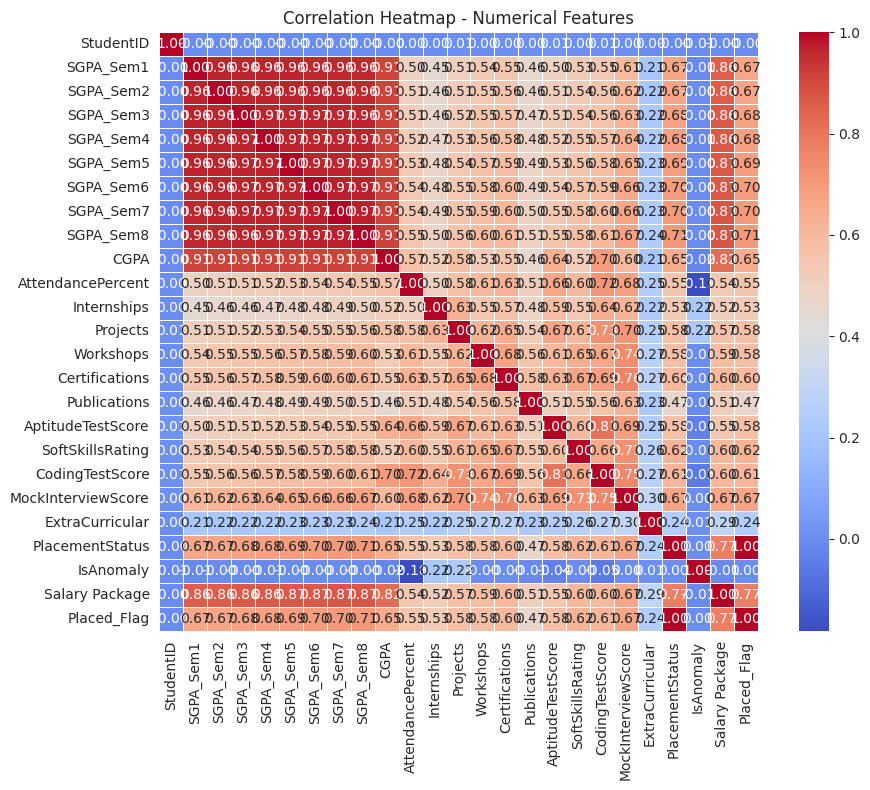

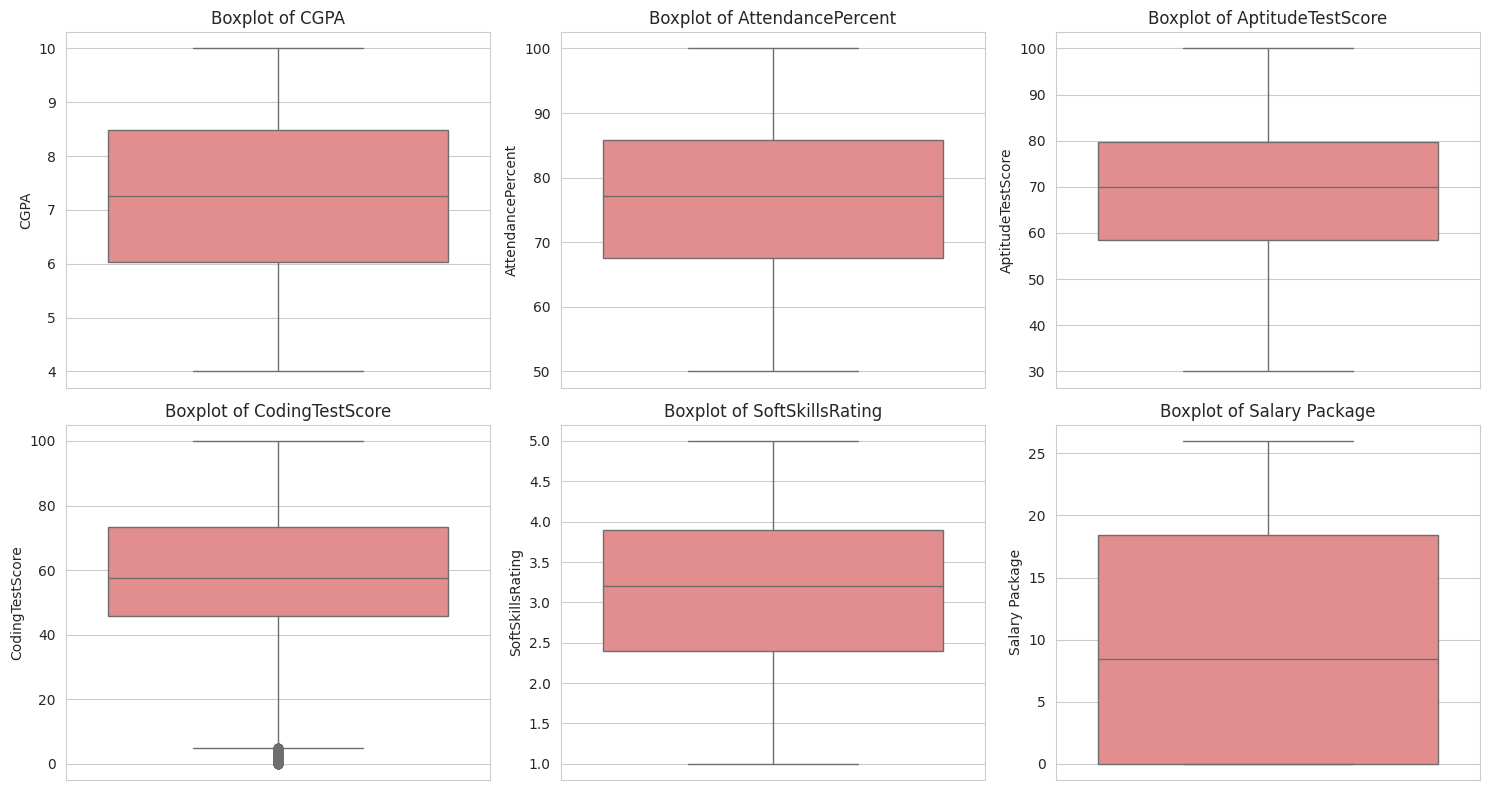

EDA report saved as EDA_report.pdf


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")

df = pd.read_csv("placement_predict_50k Dataset.csv")

df.head(5)

df.tail(6)

print("\nShape of dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

df['Placed_Flag'] = df['PlacementStatus'] # Corrected: Directly assign PlacementStatus as it's already 0/1
num_cols = ['CGPA', 'AttendancePercent', 'AptitudeTestScore',
            'CodingTestScore', 'SoftSkillsRating', 'Salary Package']
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

g3 = plt.figure(figsize=(10, 6))

placement_rate = (
    df.groupby('Stream')['Placed_Flag'].mean().sort_values(ascending=False) * 100
)

sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')
plt.title('Placement Rate (%) by Stream')
plt.xlabel('Stream')
plt.ylabel('Placement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPlacement rate (%) by stream:")
print(placement_rate.round(2))

fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

pdf = PdfPages("EDA_report.pdf")

pdf.savefig(fig1)
pdf.savefig(fig2)
pdf.savefig(g3)
pdf.savefig(fig4)
pdf.savefig(fig5)
pdf.close()

print("EDA report saved as EDA_report.pdf")